<a href="https://colab.research.google.com/github/Inventor-creator/Learning-Machine-Learning-and-Deep-Learning/blob/main/learning_basic_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
import torch
from torch import relu

In [ ]:
# Define a simple model
class SimpleModel(nn.Module):
  def __init__(self):
    super(SimpleModel, self).__init__()
    self.relu = nn.Linear(10, 5) # Input size 10, output size 5
  def forward(self, x):
    return self.relu(x)


# Check CUDA availability
if torch.cuda.is_available():
  device = torch.device('cuda')
  print("CUDA is available! Training on GPU...")
else:
  device = torch.device('cpu')
  print("CUDA is NOT available. Training on CPU...")
# Instantiate the model
model = SimpleModel()
# Move the model to the GPU
model.to(device)
# Create some sample input data
input_data = torch.randn(1, 10)  # Batch size 1, input size 10
# Move the input data to the GPU
input_data = input_data.to(device)
# Perform a forward pass
output = model(input_data)
print("Output:", output)
print("Output Device:", output.device)

CUDA is NOT available. Training on CPU...
Output: tensor([[-0.7341,  0.0107,  0.5737,  0.1718,  0.0651]],
       grad_fn=<AddmmBackward0>)
Output Device: cpu


In [ ]:
tensor = torch.randint( size=(5,10,2), low=10 , high=20 )

In [ ]:
tensor

tensor([[[19, 17],
         [16, 11],
         [15, 13],
         [14, 19],
         [12, 18],
         [18, 11],
         [11, 19],
         [17, 14],
         [15, 19],
         [14, 10]],

        [[13, 10],
         [10, 12],
         [13, 19],
         [12, 16],
         [14, 12],
         [15, 11],
         [15, 18],
         [15, 17],
         [13, 15],
         [18, 17]],

        [[11, 13],
         [11, 17],
         [18, 12],
         [17, 15],
         [17, 14],
         [17, 18],
         [11, 18],
         [19, 11],
         [16, 11],
         [15, 10]],

        [[14, 13],
         [14, 11],
         [15, 18],
         [15, 13],
         [17, 18],
         [12, 12],
         [10, 14],
         [12, 19],
         [12, 18],
         [15, 11]],

        [[17, 13],
         [12, 14],
         [11, 18],
         [19, 11],
         [19, 14],
         [10, 19],
         [17, 16],
         [12, 13],
         [12, 12],
         [12, 18]]])

In [ ]:
tensor2 = torch.arange(50)

In [ ]:
tensor2

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

In [ ]:
tensor2.reshape(5,10,-1)

tensor([[[ 0],
         [ 1],
         [ 2],
         [ 3],
         [ 4],
         [ 5],
         [ 6],
         [ 7],
         [ 8],
         [ 9]],

        [[10],
         [11],
         [12],
         [13],
         [14],
         [15],
         [16],
         [17],
         [18],
         [19]],

        [[20],
         [21],
         [22],
         [23],
         [24],
         [25],
         [26],
         [27],
         [28],
         [29]],

        [[30],
         [31],
         [32],
         [33],
         [34],
         [35],
         [36],
         [37],
         [38],
         [39]],

        [[40],
         [41],
         [42],
         [43],
         [44],
         [45],
         [46],
         [47],
         [48],
         [49]]])

In [ ]:
tensor + tensor2.reshape(5,10,-1)

tensor([[[19, 17],
         [17, 12],
         [17, 15],
         [17, 22],
         [16, 22],
         [23, 16],
         [17, 25],
         [24, 21],
         [23, 27],
         [23, 19]],

        [[23, 20],
         [21, 23],
         [25, 31],
         [25, 29],
         [28, 26],
         [30, 26],
         [31, 34],
         [32, 34],
         [31, 33],
         [37, 36]],

        [[31, 33],
         [32, 38],
         [40, 34],
         [40, 38],
         [41, 38],
         [42, 43],
         [37, 44],
         [46, 38],
         [44, 39],
         [44, 39]],

        [[44, 43],
         [45, 42],
         [47, 50],
         [48, 46],
         [51, 52],
         [47, 47],
         [46, 50],
         [49, 56],
         [50, 56],
         [54, 50]],

        [[57, 53],
         [53, 55],
         [53, 60],
         [62, 54],
         [63, 58],
         [55, 64],
         [63, 62],
         [59, 60],
         [60, 60],
         [61, 67]]])

In [3]:
import pandas as pd

df = pd.read_csv('Titanic-Dataset.csv')



In [4]:
print(df.columns)
types = []
for i in df.columns:
  types.append(type(i))

print(types)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
[<class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>]


In [5]:
yTarget = df['Survived']

In [6]:
temp = np.array([])
for i in yTarget:
    if i == 0:
        temp = np.append(temp , 1)
    else:
        temp = np.append(temp , 0)



In [7]:

#yTarget = torch.tensor(yTarget , dtype=torch.float32)


In [8]:

yTarget = torch.tensor(yTarget )


In [9]:
df.drop(columns=['Name','Fare','Survived','Ticket'], inplace=True)

In [10]:
?Pipeline

Object `Pipeline` not found.


In [11]:
def cabinSort(cabinNum ):

  if cabinNum is np.nan:
    return '0'
  else:
    return cabinNum[0]



df['Cabin'] = df['Cabin'].apply(cabinSort)
df['Embarked'] = df['Embarked'].fillna('nan')

In [12]:
df.isna().any()

,0
PassengerId,False
Pclass,False
Sex,False
Age,True
SibSp,False
Parch,False
Cabin,False
Embarked,False


In [13]:
df['Embarked']

,Embarked
0,S
1,C
2,S
3,S
4,S
...,...
886,S
887,S
888,S
889,C


In [14]:
yTarget.shape

torch.Size([891])

In [15]:
df['Age'].fillna(-1, inplace=True)


/tmp/ipykernel_10135/1435753638.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(-1, inplace=True)


In [16]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
cols = df.columns



transformer = ColumnTransformer([
    ('labelEncoder', OrdinalEncoder() , ['Sex', 'Cabin', "Embarked"]),


], remainder='passthrough')

normalizerPipe = Pipeline(steps=[
    ("transformer" , transformer),
    ("scaler",StandardScaler())
])

df = normalizerPipe.fit_transform(df)

In [17]:
df

array([[ 0.73769513, -0.48846066,  0.58111394, ..., -0.0896342 ,
         0.43279337, -0.47367361],
       [-1.35557354,  1.39832453, -1.93846038, ...,  0.80634954,
         0.43279337, -0.47367361],
       [-1.35557354, -0.48846066,  0.58111394, ...,  0.13436174,
        -0.4745452 , -0.47367361],
       ...,
       [-1.35557354, -0.48846066,  0.58111394, ..., -1.37761082,
         0.43279337,  2.00893337],
       [ 0.73769513,  1.39832453, -1.93846038, ...,  0.13436174,
        -0.4745452 , -0.47367361],
       [ 0.73769513, -0.48846066, -0.67867322, ...,  0.47035564,
        -0.4745452 , -0.47367361]])

In [18]:
df[0]

array([ 0.73769513, -0.48846066,  0.58111394, -1.73010796,  0.82737724,
       -0.0896342 ,  0.43279337, -0.47367361])

In [19]:
cleanedDataTensor = torch.tensor(df)
len(cleanedDataTensor)


891

In [20]:

class Network(nn.Module):
    def __init__(self):
        super(Network, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16,1)
        )

    def forward(self, x):
        x = self.layers(x)
        return x

In [21]:
type(yTarget[0])

torch.Tensor

In [28]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
model = Network()
loss = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(model.parameters(), lr=0.005 ,weight_decay=0.01)
# scheduler = ReduceLROnPlateau(optimizer)
dataset = TensorDataset(cleanedDataTensor, yTarget.reshape(yTarget.shape[0] , -1))
dataloader = DataLoader(dataset, batch_size=32 ,shuffle=True)


In [29]:
epochs = 100

epochNum = []
lossatNum = []

for i in range(epochs):
  for inputs,targets in dataloader:

    optimizer.zero_grad()
    outputs = model.forward(inputs.to(torch.float32))
    # print(outputs)
    loss_value = loss(outputs, targets.to(torch.float32))
    loss_value.backward()
    optimizer.step()
    # scheduler.step(loss_value)

  epochNum.append(i+1)
  lossatNum.append(loss_value.item())
  print(f"Epoch {i+1}/{epochs}, Loss: {loss_value.item()}")


Epoch 1/100, Loss: 0.716804027557373
Epoch 2/100, Loss: 0.6655294895172119
Epoch 3/100, Loss: 0.6862215399742126
Epoch 4/100, Loss: 0.6733337044715881
Epoch 5/100, Loss: 0.6679041385650635
Epoch 6/100, Loss: 0.6548762917518616
Epoch 7/100, Loss: 0.6813355684280396
Epoch 8/100, Loss: 0.6980502605438232
Epoch 9/100, Loss: 0.6593368649482727
Epoch 10/100, Loss: 0.615215003490448
Epoch 11/100, Loss: 0.6571406126022339
Epoch 12/100, Loss: 0.591977596282959
Epoch 13/100, Loss: 0.6091797351837158
Epoch 14/100, Loss: 0.6298393607139587
Epoch 15/100, Loss: 0.6095109581947327
Epoch 16/100, Loss: 0.6095429062843323
Epoch 17/100, Loss: 0.6199553608894348
Epoch 18/100, Loss: 0.5973761081695557
Epoch 19/100, Loss: 0.6069436073303223
Epoch 20/100, Loss: 0.591346263885498
Epoch 21/100, Loss: 0.5174427032470703
Epoch 22/100, Loss: 0.6613273620605469
Epoch 23/100, Loss: 0.6061089634895325
Epoch 24/100, Loss: 0.5473257899284363
Epoch 25/100, Loss: 0.5939804911613464
Epoch 26/100, Loss: 0.5547711849212646

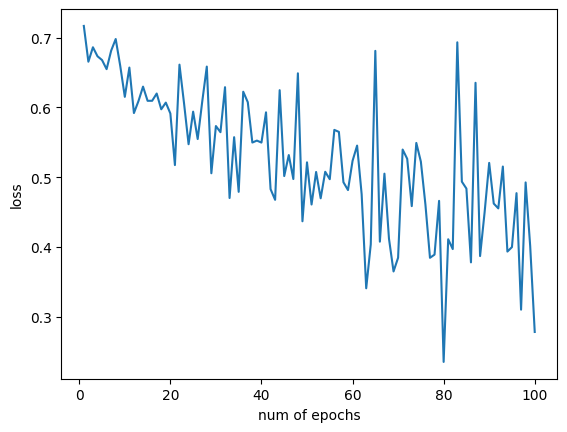

In [30]:
import matplotlib.pyplot as plt

plt.plot(epochNum , lossatNum)

plt.xlabel("num of epochs")
plt.ylabel("loss")
plt.show()